In [1]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt 
import torch
from sklearn.model_selection import train_test_split


In [2]:
df_hours=pd.read_csv('hour.csv'
                    ,index_col=0)
df_hours.head()


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,,
1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
print(df_hours.shape)
print(df_hours.columns)

(17379, 16)
Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [4]:
target_y=df_hours.cnt


array([[<Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'yr'}>, <Axes: title={'center': 'mnth'}>,
        <Axes: title={'center': 'hr'}>],
       [<Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'workingday'}>,
        <Axes: title={'center': 'weathersit'}>],
       [<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>,
        <Axes: title={'center': 'windspeed'}>],
       [<Axes: title={'center': 'casual'}>,
        <Axes: title={'center': 'registered'}>,
        <Axes: title={'center': 'cnt'}>, <Axes: >]], dtype=object)

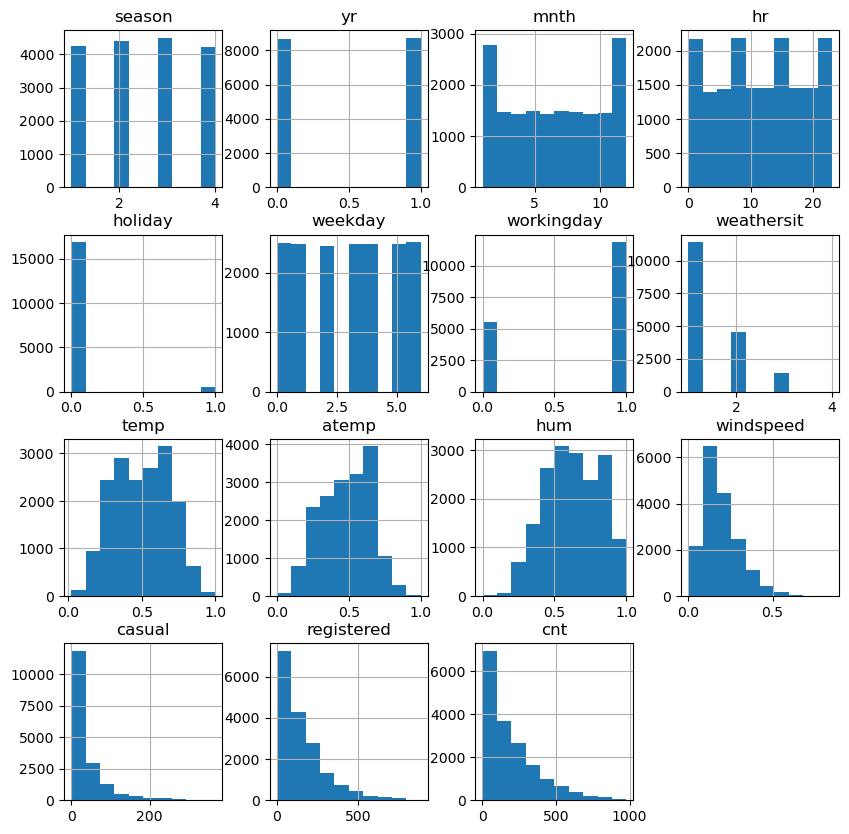

In [5]:
df_hours.hist(figsize=(10,10))


In [6]:
df_hours.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

<Axes: xlabel='yr', ylabel='cnt'>

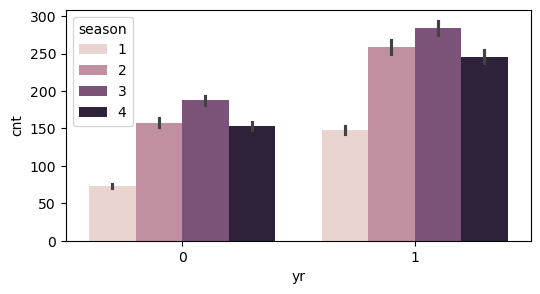

In [7]:
plt.figure(figsize=(6,3))
sns.barplot(x='yr',y='cnt',hue='season',data=df_hours)


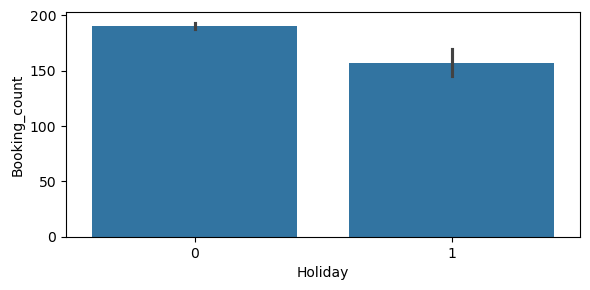

In [8]:
plt.figure(figsize=(6,3))
sns.barplot(x='holiday',y='cnt',data=df_hours)
plt.xlabel("Holiday")
plt.ylabel("Booking_count")
plt.tight_layout()

In [9]:
map={1:'Spring',2:'Summer',3:'Fall',4:'Winter'}

In [10]:
df_hours['season'].map(map)
df_hours['season']=df_hours['season'].map(map)

In [11]:
df_hours.head(2)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,,
1,2011-01-01,Spring,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2,2011-01-01,Spring,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40


In [12]:
#one Hot Encoding
pd.get_dummies(df_hours,columns=['season'])
df_hours=pd.get_dummies(df_hours,columns=['season'])

In [13]:
print(int(True))
print(int(False))
df_hours.head()



1
0


,dteday,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_Fall,season_Spring,season_Summer,season_Winter
instant,,,,,,,,,,,,,,,,,,,
1,2011-01-01,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,False,True,False,False
2,2011-01-01,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,False,True,False,False
3,2011-01-01,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,False,True,False,False
4,2011-01-01,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,False,True,False,False
5,2011-01-01,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,False,True,False,False


In [14]:
df_hours.columns

Index(['dteday', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt', 'season_Fall', 'season_Spring', 'season_Summer',
       'season_Winter'],
      dtype='object')

In [15]:
from sklearn.model_selection import train_test_split
x_features=df_hours[['registered','holiday','weekday',
       'workingday', 'weathersit', 'temp', 'atemp','season_Fall', 'season_Spring',
       'season_Summer', 'season_Winter']]

y_target=df_hours[['cnt']]
x_features=x_features.astype(float)
y_target=y_target.astype(float)

tra_x,tes_x,tra_y,tes_y=train_test_split(x_features,y_target,test_size=0.2)
len(tra_x)




13903

In [16]:
from torch import tensor
ten_x_train=torch.tensor(tra_x.values,dtype=torch.float)
tex_x_test=torch.tensor(tes_x.values,dtype=torch.float)
ten_y_train=torch.tensor(tra_y.values,dtype=torch.float)
tex_y_test=torch.tensor(tes_y.values,dtype=torch.float)
len(ten_x_train)

13903

In [17]:
## Utils

import torch.utils.data as data_utils

train_data_tensor_utile=data_utils.TensorDataset(ten_x_train,ten_y_train)
len(train_data_tensor_utile)
len(ten_x_train)


13903

In [18]:
# Now make it into batch
train_data_loader=data_utils.DataLoader(train_data_tensor_utile,batch_size=100)
len(train_data_loader)



140

In [31]:

#model Layers 
ten_x_train.shape
input_layer=ten_x_train.shape[1]

Hidden_layer=10
output_layer=1

In [32]:
# Model and droput
model = torch.nn.Sequential(torch.nn.Linear(input_layer,Hidden_layer),
                             #torch.nn.ReLU(),
                             torch.nn.Dropout(p=0.2),
                             torch.nn.Linear(Hidden_layer,output_layer))

In [35]:
#adam optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [44]:
for i,(feature,target) in enumerate(train_data_loader):
    print(feature)

tensor([[124.,   0.,   1.,  ...,   1.,   0.,   0.],
        [148.,   0.,   1.,  ...,   0.,   0.,   0.],
        [119.,   0.,   1.,  ...,   0.,   0.,   0.],
        ...,
        [  3.,   0.,   3.,  ...,   1.,   0.,   0.],
        [176.,   0.,   1.,  ...,   1.,   0.,   0.],
        [ 76.,   0.,   0.,  ...,   0.,   0.,   1.]])
tensor([[268.,   0.,   0.,  ...,   0.,   0.,   0.],
        [212.,   0.,   0.,  ...,   1.,   0.,   0.],
        [ 90.,   0.,   6.,  ...,   1.,   0.,   0.],
        ...,
        [115.,   0.,   0.,  ...,   1.,   0.,   0.],
        [208.,   0.,   5.,  ...,   0.,   1.,   0.],
        [  3.,   0.,   2.,  ...,   1.,   0.,   0.]])
tensor([[33.,  0.,  4.,  ...,  0.,  0.,  0.],
        [32.,  0.,  4.,  ...,  0.,  1.,  0.],
        [12.,  0.,  4.,  ...,  0.,  1.,  0.],
        ...,
        [16.,  0.,  6.,  ...,  1.,  0.,  0.],
        [19.,  1.,  4.,  ...,  0.,  0.,  1.],
        [ 4.,  0.,  2.,  ...,  0.,  1.,  0.]])
tensor([[122.,   0.,   3.,  ...,   1.,   0.,   0.],
      

In [46]:
# error
loss_fn=torch.nn.MSELoss()

In [80]:
for epoch in range(350):
    for i,(feature,target) in enumerate(train_data_loader):
        model_output=model(feature)
        error=loss_fn(model_output,target)
        optimizer.zero_grad()
        error.backward()
        optimizer.step()

  

In [81]:
model.eval()
with torch.no_grad():
    y_hat=model(tex_x_test)
    


In [82]:
tes_y
mse=loss_fn(tex_y_test,y_hat)
rmse=np.sqrt(mse)
print(rmse)

tensor(34.7029)


C:\Users\Sachi\AppData\Local\Temp\ipykernel_25088\3966912984.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse=np.sqrt(mse)
